In [11]:
import torch
#from instanseg import InstanSeg
from skimage import io
import matplotlib.pyplot as plt
from skimage.measure import regionprops_table
import numpy as np
import pandas as pd
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2hsv
from skimage.morphology import binary_closing, disk, remove_small_objects
from scipy.ndimage import binary_fill_holes
import cv2
from skimage.filters import threshold_otsu
import histomicstk.features as htk_features
from cellpose import models
import histomicstk as htk
from histomicstk.features import compute_nuclei_features
import seaborn as sns
from skimage.measure import label, regionprops_table
from numpy.linalg import LinAlgError

In [2]:
# 初始化模型（nuclei专用）
model = models.CellposeModel(gpu=True)

### IHC Image

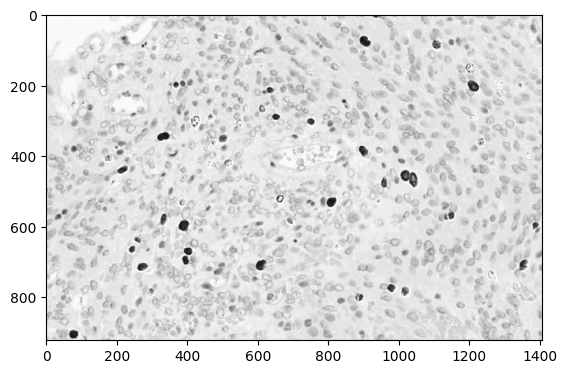

: 

In [ ]:
image = io.imread(r'c:\Users\Eric\OneDrive - Johns Hopkins\xwechat_files\wxid_t5w5u095diir12_4a30\temp\RWTemp\2026-04\9e20f478899dc29eb19741386f9343c8\ffc4dd5df85447439251bf863d743644.png')  # 替换为你的图像路径
def deconvolution_ihc_ki67_dynamic(img_rgb):
    I_0 = 255
    stain_color_map = htk.preprocessing.color_deconvolution.stain_color_map

    try:
        # 1) 动态估计 stain matrix
        W_estimated = htk.preprocessing.color_deconvolution.rgb_separate_stains_macenko_pca(
            img_rgb, I_0
        )

        # 2) 在估计出的 stain 中，找最接近 hematoxylin / DAB 的方向
        h_index = htk.preprocessing.color_deconvolution.find_stain_index(
            stain_color_map['hematoxylin'], W_estimated
        )
        d_index = htk.preprocessing.color_deconvolution.find_stain_index(
            stain_color_map['dab'], W_estimated
        )

        # 防止两个 stain 被匹配到同一列
        if h_index == d_index:
            raise ValueError("Estimated stain vectors are not well separated.")

        # 3) 组装自定义 stain matrix
        W_custom = np.zeros((3, 3))
        W_custom[:, 0] = W_estimated[:, h_index]
        W_custom[:, 1] = W_estimated[:, d_index]

        # 4) 补第三个正交 stain
        W_custom = htk.preprocessing.color_deconvolution.complement_stain_matrix(W_custom)

        # 5) 解卷积
        deconv_result = htk.preprocessing.color_deconvolution.color_deconvolution(
            img_rgb, W_custom, I_0
        )

    except (LinAlgError, IndexError, ValueError):
        print("Dynamic stain estimation failed. Using default H-DAB matrix.")
        stains = ['hematoxylin', 'dab', 'null']
        W_custom = np.array([stain_color_map[st] for st in stains]).T
        deconv_result = htk.preprocessing.color_deconvolution.color_deconvolution(
            img_rgb, W_custom, I_0
        )

    im_nuclei = deconv_result.Stains[:, :, 0]   # H channel
    im_dab = deconv_result.Stains[:, :, 1]      # DAB channel
    return im_nuclei, im_dab

im_nuclei, im_dab = deconvolution_ihc_ki67_dynamic(image)

plt.imshow(im_nuclei, cmap='gray')

### HE Image

正在运行分割...
Eccentricity Mean: 0.6845222583749967
Eccentricity Median: 0.7043584350413982
Eccentricity Mid50 Mean: 0.7017907228168742
Eccentricity Std: 0.17014058700505902
mask unique values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
max label: 149


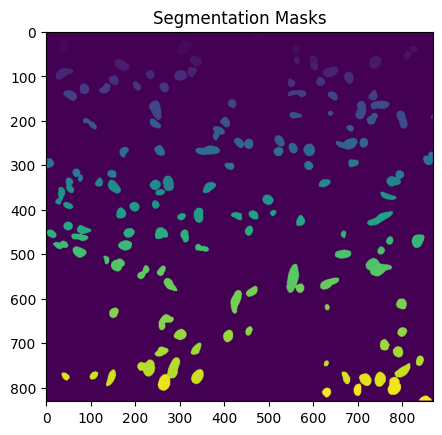

In [3]:
path = r"c:\Users\Eric\OneDrive - Johns Hopkins\xwechat_files\wxid_t5w5u095diir12_4a30\temp\RWTemp\2026-04\dd7e95cfc27ffc243856336fc4e279f5.png"
img = io.imread(path)

print("正在运行分割...")
# 运行分割
masks, _,_ = model.eval(img)
plt.imshow(masks)
plt.title("Segmentation Masks")

ecc_mean = 0.0
ecc_median = 0.0
ecc_mid50_mean = 0.0
ecc_std = 0.0

props = regionprops_table(masks, properties=['eccentricity'])
ecc_values = props['eccentricity']

if len(ecc_values) > 0:
    # 1. 全部均值 (Mean)
    ecc_mean = np.mean(ecc_values)
    # 2. 中位数 (Median)
    ecc_median = np.median(ecc_values)
    # 3. 标准差 (Standard Deviation)
    ecc_std = np.std(ecc_values)
    
    # 4. 中间 50% 的均值
    q1 = np.percentile(ecc_values, 25)
    q3 = np.percentile(ecc_values, 75)
    middle_50_ecc = ecc_values[(ecc_values >= q1) & (ecc_values <= q3)]
    if len(middle_50_ecc) > 0:
        ecc_mid50_mean = np.mean(middle_50_ecc)

print(f"Eccentricity Mean: {ecc_mean}")
print(f"Eccentricity Median: {ecc_median}")
print(f"Eccentricity Mid50 Mean: {ecc_mid50_mean}")
print(f"Eccentricity Std: {ecc_std}")
print("mask unique values:", np.unique(masks)[:20])
print("max label:", masks.max())
from skimage.measure import label

labeled_mask = label(masks)
tiff.imwrite(r"d:\UofT\2025fall\OnSight\mask.tif", masks.astype("int32"))

In [ ]:
PATH = r'D:\UofT\2025fall\OnSight\Revisions\Figures\Tsne\Data\patch.png'
MPP = 0.228  # Microns per pixel (微米/像素)

print(f"加载图像: {PATH}")
img = io.imread(PATH)

# ==========================================
# 2. 细胞核分割
# ==========================================
print("正在运行分割...")
masks, _, _ = model.eval(img)

# ==========================================
# 3. 颜色反卷积 (Macenko PCA)
# ==========================================
print("正在进行颜色反卷积...")
I_0 = 255
stain_color_map = htk.preprocessing.color_deconvolution.stain_color_map

# 估计染色矩阵并寻找 H 和 E 的索引
W_estimated = htk.preprocessing.color_deconvolution.rgb_separate_stains_macenko_pca(img, I_0)
h_index = htk.preprocessing.color_deconvolution.find_stain_index(stain_color_map['hematoxylin'], W_estimated)
e_index = htk.preprocessing.color_deconvolution.find_stain_index(stain_color_map['eosin'], W_estimated)

# 构建专属解卷积矩阵
W_custom = np.zeros((3, 3))
W_custom[:, 0] = W_estimated[:, h_index]
W_custom[:, 1] = W_estimated[:, e_index]
W_custom = htk.preprocessing.color_deconvolution.complement_stain_matrix(W_custom)

# 执行颜色反卷积并提取单通道
deconv_result = htk.preprocessing.color_deconvolution.color_deconvolution(img, W_custom, I_0)
im_nuclei_accurate = deconv_result.Stains[:, :, 0]
im_cytoplasm = deconv_result.Stains[:, :, 1]

# 可视化提取的细胞核通道 (可选)
# plt.imshow(im_nuclei_accurate, cmap="gray")
# plt.title("Accurate Nuclei Channel")
# plt.show()
#masks = clear_border(masks)
# ==========================================
# 4. 特征计算与物理单位 (MPP) 转换
# ==========================================
print("正在计算特征...")
features_df = compute_nuclei_features(
    im_label=masks,
    im_nuclei=im_nuclei_accurate,       
    morphometry_features_flag=True,
    fsd_features_flag=False,
    intensity_features_flag=True,
    gradient_features_flag=False,
    haralick_features_flag=False
)

# 转换物理单位 (像素 -> 微米)
# 面积 = 像素面积 * (MPP ^ 2)
if 'Size.Area' in features_df.columns:
    features_df['Size.Area'] = features_df['Size.Area'] * (MPP ** 2)

# 长度/周长 = 像素长度 * MPP
length_features = ['Size.MajorAxisLength', 'Shape.EquivalentDiameter', 'Size.Perimeter']
for col in length_features:
    if col in features_df.columns:
        features_df[col] = features_df[col] * MPP

# ==========================================
# 5. 统计与报告打印
# ==========================================
categories = {
    "Nuclear Size (细胞核大小/肥大程度) [单位: µm 或 µm²]": [
        'Size.Area', 'Size.MajorAxisLength', 'Shape.EquivalentDiameter', 'Size.Perimeter',"Size.EquivalentDiameter"
    ],
    "Nuclear Shape (细胞核形状/异型性) [无量纲]": [
        'Shape.Circularity', 'Shape.Eccentricity', 'Shape.Solidity', 'Shape.Extent'
    ],
    "Nuclear Intensity (染色强度/深染程度) [灰度值]": [
        'Nucleus.Intensity.Mean', 'Nucleus.Intensity.HistEnergy', 'Nucleus.Intensity.Std', 
        'Nucleus.Intensity.IQR', 'Nucleus.Intensity.HistEntropy'
    ]
}

# 展平目标列以计算均值
target_columns = [col for cols in categories.values() for col in cols]
existing_cols = [c for c in target_columns if c in features_df.columns]
all_cells_mean = features_df[existing_cols].mean()

print("\n" + "="*65)
print(f"病理特征统计报告 | 样本: ...{PATH[-30:]}")
print(f"检测到的细胞总数: {len(features_df)}")
print("="*65)

for cat_name, cols in categories.items():
    print(f"\n>>> {cat_name}:")
    for col in cols:
        if col in all_cells_mean:
            print(f"    {col:30} : {all_cells_mean[col]:>10.4f}")
        else:
            print(f"    {col:30} : [未计算 - 请检查Flag设置]")

print("\n" + "="*65)

Found more than 3 channels, only using first 3


正在运行分割...
正在计算特征...


ValueError: incompatible dimensions for cross product
(dimension must be 2 or 3)

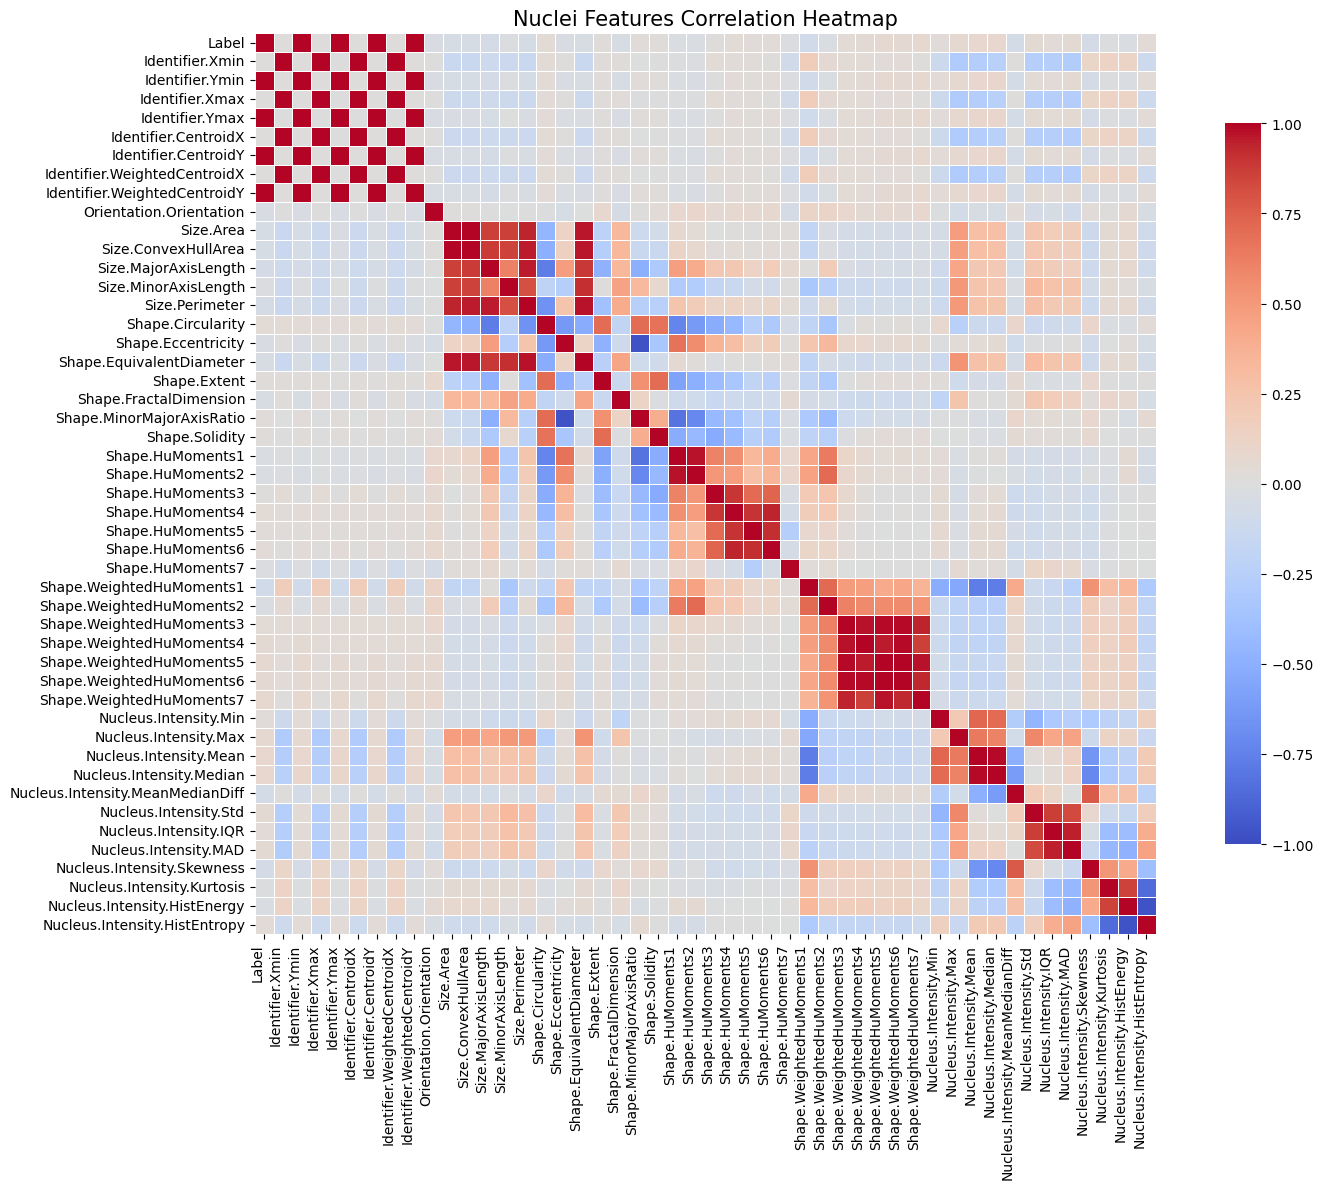

: 

In [ ]:
numeric_df = features_df.select_dtypes(include=[np.number])
numeric_df = numeric_df.loc[:, numeric_df.std() > 0]
corr_matrix = numeric_df.corr()
plt.figure(figsize=(16, 12))

# 使用 seaborn 绘制热力图
# cmap: 颜色映射，'RdBu_r' 或 'coolwarm' 很适合表现正负相关性
# annot: 是否在格子里显示数值。如果特征 > 20 个，建议设为 False
sns.heatmap(corr_matrix, 
            annot=len(corr_matrix.columns) < 20, 
            fmt=".2f", 
            cmap='coolwarm', 
            vmin=-1, vmax=1,  # 相关系数范围是 [-1, 1]
            center=0,
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title('Nuclei Features Correlation Heatmap', fontsize=15)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
I_0 = 255

# 运行 Macenko PCA 算法估计矩阵
W_estimated = htk.preprocessing.color_deconvolution.rgb_separate_stains_macenko_pca(img, I_0)


# --- 2. 匹配与重排染色通道（千万不能漏掉这一步！） ---
# 【避坑指南】：算法自动找出的两个特征向量是“不分先后”的。
# 它不知道哪一列是苏木精，哪一列是伊红。我们需要手动将它们与标准颜色进行匹配。

stain_color_map = htk.preprocessing.color_deconvolution.stain_color_map

# 找到 W_estimated 中最接近“标准苏木精”颜色的那一列的索引
h_index = htk.preprocessing.color_deconvolution.find_stain_index(
    stain_color_map['hematoxylin'], W_estimated
)

# 找到最接近“标准伊红”的那一列的索引
e_index = htk.preprocessing.color_deconvolution.find_stain_index(
    stain_color_map['eosin'], W_estimated
)

# 构造一个排好序的专属矩阵：第一列强制为苏木精，第二列强制为伊红
W_custom = np.zeros((3, 3))
W_custom[:, 0] = W_estimated[:, h_index]
W_custom[:, 1] = W_estimated[:, e_index]

# 第三列通常由前两列计算叉乘生成（代表背景/无染色区域）
W_custom = htk.preprocessing.color_deconvolution.complement_stain_matrix(W_custom)


# --- 3. 使用专属矩阵进行精准的颜色反卷积 ---
deconv_result = htk.preprocessing.color_deconvolution.color_deconvolution(
    img, W_custom, I_0
)

# --- 4. 提取出极其精准的单通道图像 ---
im_nuclei_accurate = deconv_result.Stains[:, :, 0]
im_cytoplasm_accurate = deconv_result.Stains[:, :, 1]

# 现在，你可以将 im_nuclei_accurate 放心大胆地喂给 compute_nuclei_features 函数了！

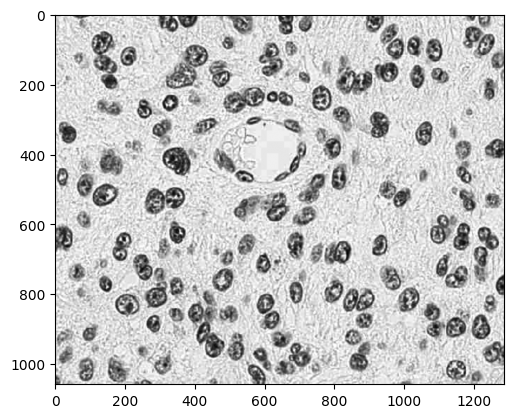

In [38]:
plt.imshow(im_nuclei_accurate, cmap="gray")

In [98]:
img_rgb = img  # uint8, RGB (注意是RGB不是BGR)
img_od = htk.preprocessing.color_conversion.rgb_to_od(img_rgb)

stain_color_map = htk.preprocessing.color_deconvolution.stain_color_map
W = np.array([
    stain_color_map['hematoxylin'],
    stain_color_map['eosin'],
    stain_color_map['null']
]).T  # 3x3, columns are stain vectors

deconv = htk.preprocessing.color_deconvolution.color_deconvolution(img_od, W)

im_nuclei = deconv.Stains[:, :, 0]
im_cytoplasm = deconv.Stains[:, :, 1]

In [70]:
from histomicstk.features import compute_nuclei_features
features_df = compute_nuclei_features(
    im_label=masks,
    im_nuclei=im_nuclei,           # <--- 填入这里
   # im_cytoplasm=im_cytoplasm,     # <--- (可选) 如果你想算细胞质特征，填入这里
    # morphometry_features_flag=False,
    # fsd_features_flag=True,
    # intensity_features_flag=False,
    # gradient_features_flag=False,
    # haralick_features_flag=False
)

d:\UofT\2025fall\OnSight\OnSight_Pathology\.venv\Lib\site-packages\histomicstk\features\compute_nuclei_features.py:190: FutureWarning: `RegionProperties.weighted_centroid` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.centroid_weighted` instead. 
  wcy, wcx = nprop.weighted_centroid
d:\UofT\2025fall\OnSight\OnSight_Pathology\.venv\Lib\site-packages\histomicstk\features\compute_morphometry_features.py:156: FutureWarning: `RegionProperties.convex_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_convex` instead. 
  value = getattr(prop, attr, np.nan)
d:\UofT\2025fall\OnSight\OnSight_Pathology\.venv\Lib\site-packages\histomicstk\features\compute_morphometry_features.py:156: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  value = getattr(prop, attr, np.

In [58]:
from skimage.color import rgb2hed

hed = rgb2hed(img)
hematoxylin = hed[:, :, 0]

features = htk_features.compute_nuclei_features(
    im_label=masks,
    im_nuclei=hematoxylin,
    morphometry_features_flag=True,
    fsd_features_flag=True,
    intensity_features_flag=False,
    gradient_features_flag=False,
    haralick_features_flag=False
)
print(features.to_string())

    Label  Identifier.Xmin  Identifier.Ymin  Identifier.Xmax  Identifier.Ymax  Identifier.CentroidX  Identifier.CentroidY  Identifier.WeightedCentroidX  Identifier.WeightedCentroidY  Orientation.Orientation  Size.Area  Size.ConvexHullArea  Size.MajorAxisLength  Size.MinorAxisLength  Size.Perimeter  Shape.Circularity  Shape.Eccentricity  Shape.EquivalentDiameter  Shape.Extent  Shape.FractalDimension  Shape.MinorMajorAxisRatio  Shape.Solidity  Shape.HuMoments1  Shape.HuMoments2  Shape.HuMoments3  Shape.HuMoments4  Shape.HuMoments5  Shape.HuMoments6  Shape.HuMoments7  Shape.WeightedHuMoments1  Shape.WeightedHuMoments2  Shape.WeightedHuMoments3  Shape.WeightedHuMoments4  Shape.WeightedHuMoments5  Shape.WeightedHuMoments6  Shape.WeightedHuMoments7  Shape.FSD1  Shape.FSD2  Shape.FSD3  Shape.FSD4  Shape.FSD5  Shape.FSD6
0       1                0                4              117              143             53.620476             71.316844                     54.260525                     71.

d:\UofT\2025fall\OnSight\OnSight_Pathology\.venv\Lib\site-packages\histomicstk\features\compute_nuclei_features.py:190: FutureWarning: `RegionProperties.weighted_centroid` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.centroid_weighted` instead. 
  wcy, wcx = nprop.weighted_centroid
d:\UofT\2025fall\OnSight\OnSight_Pathology\.venv\Lib\site-packages\histomicstk\features\compute_morphometry_features.py:156: FutureWarning: `RegionProperties.convex_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_convex` instead. 
  value = getattr(prop, attr, np.nan)
d:\UofT\2025fall\OnSight\OnSight_Pathology\.venv\Lib\site-packages\histomicstk\features\compute_morphometry_features.py:156: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  value = getattr(prop, attr, np.

In [20]:
mask = masks 

props = regionprops_table(mask, properties=["label", "area", "eccentricity"])

df_cells = pd.DataFrame(props)
print(df_cells.to_string())

     label    area  eccentricity
0        1  1541.0      0.697810
1        2  2022.0      0.567640
2        3  1072.0      0.495355
3        4   375.0      0.973502
4        5  1206.0      0.556490
5        6   924.0      0.775288
6        7  1404.0      0.754526
7        8   430.0      0.726196
8        9  2339.0      0.371882
9       10   711.0      0.725516
10      11  1027.0      0.556135
11      12  1840.0      0.850152
12      13  1630.0      0.319972
13      14  3037.0      0.608288
14      15  2036.0      0.810378
15      16   832.0      0.369772
16      17  1423.0      0.734858
17      18  1953.0      0.545697
18      19  2326.0      0.704738
19      20   377.0      0.603244
20      21   976.0      0.620877
21      22  1206.0      0.413682
22      23  2982.0      0.306079
23      24  1930.0      0.624633
24      25  1479.0      0.668014
25      26  2519.0      0.781536
26      27   535.0      0.690325
27      28  1786.0      0.850613
28      29  2666.0      0.571972
29      30

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters
from skimage import morphology

# 你原来的代码
pth = r"c:\Users\Eric\OneDrive - Johns Hopkins\xwechat_files\wxid_t5w5u095diir12_4a30\temp\RWTemp\2026-03\9e20f478899dc29eb19741386f9343c8\60f707e34334fbf135ff70979c7408bd.png"
image = io.imread(pth)
from skimage.color import rgb2hsv

hsv = rgb2hsv(image)

saturation = hsv[:, :, 1]

tissue_mask = saturation > 0.05
# gray_image = color.rgb2gray(image)

# # 2. 生成组织掩膜 (Mask)
# # 方法 A: 使用 Otsu 算法自动计算最佳阈值区分前景和背景
# thresh = filters.threshold_otsu(gray_image)

# tissue_mask = gray_image < thresh*1.3
# tissue_mask = morphology.remove_small_objects(tissue_mask, max_size=500)  # 移除小于 500 像素的区域
# tissue_mask = morphology.remove_small_holes(tissue_mask,max_size=500 )  # 填充小于 500 像素的孔洞
# 3. 移除白色背景

# --- 方案 1：把背景变成黑色 ---
image_black_bg = image.copy()
# 将掩膜以外（即白色背景）的区域像素值设为 0（黑色）
image_black_bg[~tissue_mask] = 0  

# --- 方案 2：把背景变成透明 (增加 Alpha 通道) ---
# 确保原图有 3 个通道 (RGB)
# if image.shape[-1] == 3:
#     # 掩膜为 True 的地方 alpha=255 (不透明)，False 的地方 alpha=0 (透明)
#     alpha_channel = (tissue_mask * 255).astype(np.uint8)
#     image_transparent_bg = np.dstack((image, alpha_channel))
# else:
#     image_transparent_bg = image.copy()
#     image_transparent_bg[:, :, 3] = (tissue_mask * 255).astype(np.uint8)
print(np.sum(tissue_mask)/(tissue_mask.shape[0]*tissue_mask.shape[1]))
# 4. 可视化对比
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(tissue_mask, cmap='gray')
ax[1].set_title('Tissue Mask (White = Keep)')
ax[1].axis('off')

ax[2].imshow(image_black_bg) 
ax[2].set_title('Background Removed (Black)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

FileNotFoundError: No such file: 'c:\Users\Eric\OneDrive - Johns Hopkins\xwechat_files\wxid_t5w5u095diir12_4a30\temp\RWTemp\2026-03\9e20f478899dc29eb19741386f9343c8\60f707e34334fbf135ff70979c7408bd.png'

: 

In [1]:
import timm
model = timm.create_model("hf_hub:prov-gigapath/prov-gigapath")

d:\UofT\2025fall\OnSight\OnSight_Pathology\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [129]:
np.sum(tissue_mask)/(tissue_mask.shape[0]*tissue_mask.shape[1])

0.9125094425314789

Otsu threshold: 0.6376970274203431


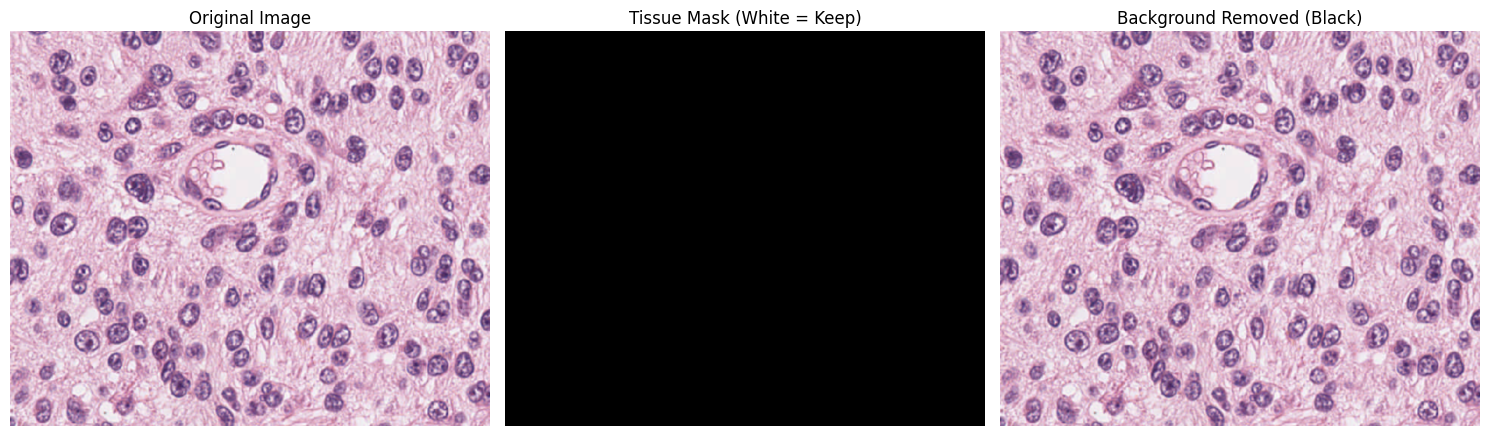

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters
from skimage import morphology

# 你原来的代码
pth = r"c:\Users\Eric\OneDrive - Johns Hopkins\xwechat_files\wxid_t5w5u095diir12_4a30\temp\RWTemp\2026-02\9e20f478899dc29eb19741386f9343c8\957e4af5c704e0a5091cc12bca3f3024.png"
image = io.imread(pth)

# 1. 将图像转换为灰度图，方便计算亮度
# 如果 image 包含 Alpha 通道 (RGBA, 4通道)，先取前三个 RGB 通道

gray_image = color.rgb2gray(image)

# 2. 生成组织掩膜 (Mask)
# 方法 A: 使用 Otsu 算法自动计算最佳阈值区分前景和背景
thresh = filters.threshold_otsu(gray_image)
print(f"Otsu threshold: {thresh}")
# 方法 B: 如果 Otsu 切掉了一些浅色组织，你可以手动设定阈值
# 因为背景是白色的，所以我们要保留灰度值 "小于" 阈值的区域（即较暗的组织部分）
#thresh = 0.8  # 如果灰度图是 0-1 范围，0.9 通常是个不错的白色背景分界线
tissue_mask = gray_image < thresh*1.5
tissue_mask = morphology.remove_small_objects(tissue_mask, max_size=500)  # 移除小于 500 像素的区域
tissue_mask = morphology.remove_small_holes(tissue_mask,max_size=500 )  # 填充小于 500 像素的孔洞
# 3. 移除白色背景

# --- 方案 1：把背景变成黑色 ---
image_black_bg = image.copy()
# 将掩膜以外（即白色背景）的区域像素值设为 0（黑色）
image_black_bg[~tissue_mask] = 0  

# --- 方案 2：把背景变成透明 (增加 Alpha 通道) ---
# 确保原图有 3 个通道 (RGB)
if image.shape[-1] == 3:
    # 掩膜为 True 的地方 alpha=255 (不透明)，False 的地方 alpha=0 (透明)
    alpha_channel = (tissue_mask * 255).astype(np.uint8)
    image_transparent_bg = np.dstack((image, alpha_channel))
else:
    image_transparent_bg = image.copy()
    image_transparent_bg[:, :, 3] = (tissue_mask * 255).astype(np.uint8)

# 4. 可视化对比
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(tissue_mask, cmap='gray')
ax[1].set_title('Tissue Mask (White = Keep)')
ax[1].axis('off')

ax[2].imshow(image_black_bg) 
ax[2].set_title('Background Removed (Black)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def get_tissue_mask_skimage(patch_rgb):
    gray = cv2.cvtColor(patch_rgb, cv2.COLOR_RGB2GRAY)
    otsu_thresh = threshold_otsu(gray)
    print(f"Otsu's threshold: {otsu_thresh}")#### True是背景，False是组织
    tissue_mask = (gray > 210)
    return gray,tissue_mask

In [31]:
def get_tissue_mask_hsv(patch_rgb, sat_threshold=50):
    hsv = cv2.cvtColor(patch_rgb, cv2.COLOR_RGB2HSV)
    s_channel = hsv[:, :, 1]
    tissue_mask = s_channel > sat_threshold
    return tissue_mask

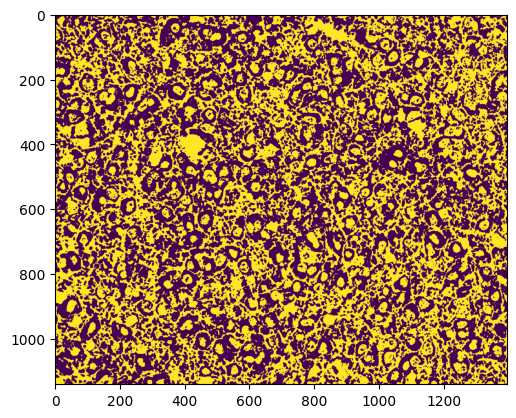

In [32]:
tissue_mask = get_tissue_mask_hsv(image)
plt.imshow(tissue_mask)

C:\Users\Eric\AppData\Local\Temp\ipykernel_19808\2084261018.py:9: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  tissue_mask = binary_closing(tissue_mask, disk(0))
C:\Users\Eric\AppData\Local\Temp\ipykernel_19808\2084261018.py:17: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  tissue_mask = remove_small_objects(tissue_mask, min_size=1000)


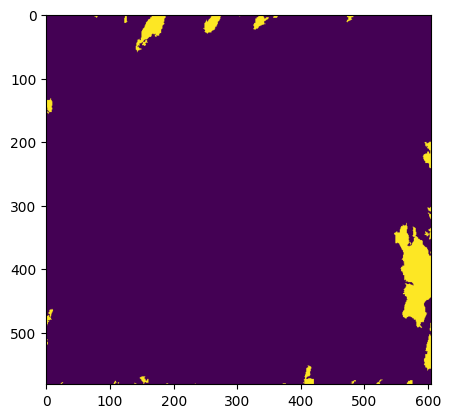

In [44]:
hsv = rgb2hsv(image)
s_channel = hsv[:, :, 1] # 饱和度通道

# 阈值经验值：0.05 是业界通用的 H&E 背景过滤阈值
# 大于 0.05 的地方被认为是“有组织”
tissue_mask = s_channel > 0.05

# 1. 闭运算 (Closing): 把断裂的组织连起来
tissue_mask = binary_closing(tissue_mask, disk(0))

# 2. 填充孔洞 (Fill Holes): 
# 把组织内部的脂肪滴、血管腔、细胞间隙都填满，算作组织区域
# 如果不做这一步，分母会变小，密度会虚高
tissue_mask = binary_fill_holes(tissue_mask)

# 3. 移除噪点: 去掉背景里的灰尘 (小于1000像素的块)
tissue_mask = remove_small_objects(tissue_mask, min_size=1000)
plt.imshow(~tissue_mask)


C:\Users\Eric\AppData\Local\Temp\ipykernel_21348\1727368988.py:37: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  tissue_mask = binary_closing(tissue_mask, disk(5))
C:\Users\Eric\AppData\Local\Temp\ipykernel_21348\1727368988.py:45: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  tissue_mask = remove_small_objects(tissue_mask, min_size=1000)


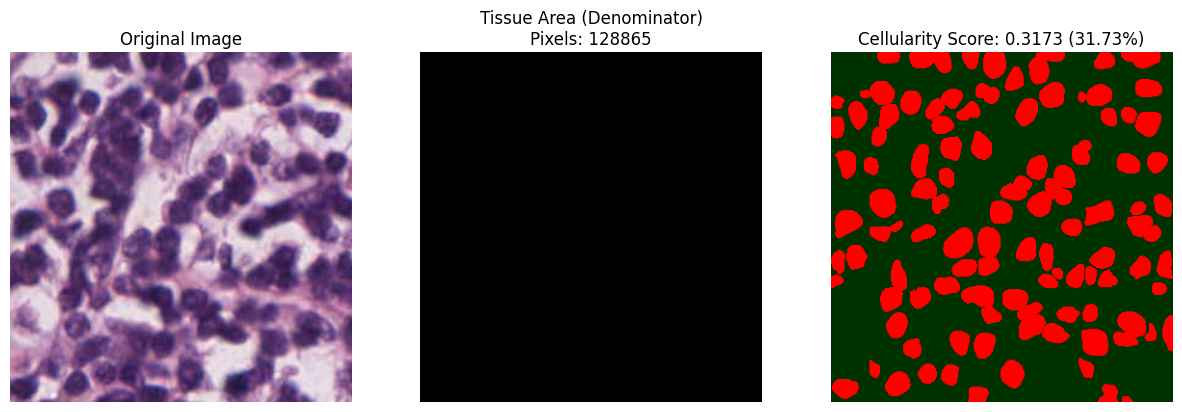

最终计算结果: 0.3173


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2hsv
from skimage.morphology import binary_closing, disk, remove_small_objects
from scipy.ndimage import binary_fill_holes

def calculate_precise_cellularity(image_rgb, nuclei_mask, show_plot=True):
    """
    计算 H&E 图像的 Cellularity (细胞核面积占比)。
    逻辑符合 HistoQC 和 TCGA 研究标准。
    
    参数:
        image_rgb: 原始 RGB 图像 (numpy array, HxWx3)
        nuclei_mask: InstanSeg/Cellpose 输出的 mask (numpy array, HxW)
        show_plot: 是否显示可视化结果 (调试用)
        
    返回:
        score: Cellularity 分数 (0.0 ~ 1.0)
        tissue_mask: 计算出的组织区域 mask (用于验证分母对不对)
    """
    
    # ---------------------------------------------------------
    # 第一步：制作精准的 Tissue Mask (分母)
    # ---------------------------------------------------------
    # H&E 染色特点：组织一定有颜色 (Saturation高)，背景通常是白的 (Saturation低)
    hsv = rgb2hsv(image_rgb)
    s_channel = hsv[:, :, 1] # 饱和度通道
    
    # 阈值经验值：0.05 是业界通用的 H&E 背景过滤阈值
    # 大于 0.05 的地方被认为是“有组织”
    tissue_mask = s_channel > 0.05
    
    # ---------------------------------------------------------
    # 第二步：形态学优化 (关键步骤！)
    # ---------------------------------------------------------
    # 1. 闭运算 (Closing): 把断裂的组织连起来
    tissue_mask = binary_closing(tissue_mask, disk(5))
    
    # 2. 填充孔洞 (Fill Holes): 
    # 把组织内部的脂肪滴、血管腔、细胞间隙都填满，算作组织区域
    # 如果不做这一步，分母会变小，密度会虚高
    tissue_mask = binary_fill_holes(tissue_mask)
    
    # 3. 移除噪点: 去掉背景里的灰尘 (小于1000像素的块)
    tissue_mask = remove_small_objects(tissue_mask, min_size=1000)
    
    # ---------------------------------------------------------
    # 第三步：计算指标 (分子 / 分母)
    # ---------------------------------------------------------
    # 只有落在 Tissue Mask 内部的细胞核才算数 (过滤掉背景脏点)
    valid_nuclei_mask = (nuclei_mask > 0) & tissue_mask
    
    nuclei_area = np.sum(valid_nuclei_mask)
    tissue_area = np.sum(tissue_mask)
    
    if tissue_area == 0:
        score = 0.0
    else:
        score = nuclei_area / tissue_area

    # ---------------------------------------------------------
    # 可视化 (可选)
    # ---------------------------------------------------------
    if show_plot:
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 3, 1)
        plt.imshow(image_rgb)
        plt.title("Original Image")
        plt.axis('off')
        
        plt.subplot(1, 3, 2)
        plt.imshow(tissue_mask, cmap='gray')
        plt.title(f"Tissue Area (Denominator)\nPixels: {tissue_area}")
        plt.axis('off')
        
        plt.subplot(1, 3, 3)
        # 叠加显示：绿色是组织，红色是细胞核
        overlay = np.zeros_like(image_rgb)
        overlay[tissue_mask] = [0, 50, 0] # 暗绿底色
        overlay[valid_nuclei_mask] = [255, 0, 0] # 红色核
        plt.imshow(overlay)
        plt.title(f"Cellularity Score: {score:.4f} ({score*100:.2f}%)")
        plt.axis('off')
        
        plt.show()
        
    return score, tissue_mask

# =========================================================
# 如何使用 (接在你之前的代码后面)
# =========================================================

# 1. 确保 mask 是 numpy 格式 (处理 InstanSeg 的 Tensor 输出)
if hasattr(labeled_output, 'cpu'):
    mask_numpy = labeled_output.detach().cpu().numpy().squeeze()
else:
    mask_numpy = labeled_output.squeeze()

# 2. 调用函数
# 注意：image 必须是 RGB (如果是 RGBA，请取前三个通道 image[:,:,:3])
cellularity_score, final_tissue_mask = calculate_precise_cellularity(image, mask_numpy)

print(f"最终计算结果: {cellularity_score:.4f}")

In [22]:
mask = labeled_output.cpu().numpy().squeeze().astype(int) 

props = regionprops_table(mask, properties=["label", "area", "eccentricity"])

df_cells = pd.DataFrame(props)
print("\n--- 单细胞特征 (Eccentricity) ---")
print(df_cells[['label', 'eccentricity', 'area']].head())
print(f"平均离心率: {df_cells['eccentricity'].mean():.4f} (0=圆, 1=长条)")


--- 单细胞特征 (Eccentricity) ---
   label  eccentricity   area
0      1      0.862906  258.0
1      2      0.746874  395.0
2      3      0.404309  266.0
3      4      0.943493  246.0
4      5      0.913637  523.0
平均离心率: 0.6592 (0=圆, 1=长条)
